# Session 5 - Percentiles, Quartiles & Boxplots


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1 — Percentiles of Zomato Delivery Times

In [3]:
delivery_times = [22, 35, 28, 40, 31, 25, 45, 30, 38, 27,
                   33, 29, 42, 26, 36, 24, 39, 32, 41, 34]

p25 = np.percentile(delivery_times, 25)
p50 = np.percentile(delivery_times, 50)
p75 = np.percentile(delivery_times, 75)

print('Delivery times (min):', delivery_times)
print('25th percentile:', p25)
print('50th percentile (median):', p50)
print('75th percentile:', p75)

Delivery times (min): [22, 35, 28, 40, 31, 25, 45, 30, 38, 27, 33, 29, 42, 26, 36, 24, 39, 32, 41, 34]
25th percentile: 27.75
50th percentile (median): 32.5
75th percentile: 38.25


## Task 2 — Quartiles of IPL Player Scores

In [4]:
ipl_scores = [45, 78, 12, 34, 89, 56, 23, 67, 90, 15, 48, 72, 33, 61, 27]

q1 = np.quantile(ipl_scores, 0.25)
q2 = np.quantile(ipl_scores, 0.50)
q3 = np.quantile(ipl_scores, 0.75)

print('Scores:', ipl_scores)
print('Q1:', q1)
print('Q2 (median):', q2)
print('Q3:', q3)

Scores: [45, 78, 12, 34, 89, 56, 23, 67, 90, 15, 48, 72, 33, 61, 27]
Q1: 30.0
Q2 (median): 48.0
Q3: 69.5


## Task 3 — IQR of Monthly Step Counts

In [5]:
monthly_steps = [6500, 7200, 8000, 6000, 9000, 7500, 8200, 6800, 7100, 9500,
                  6200, 7800, 8600, 6400, 7300, 9100, 6900, 7600, 8300, 6100,
                  7000, 8900, 6700, 7400, 9800, 6300, 7900, 8100, 6600, 7700]

steps_q1 = np.percentile(monthly_steps, 25)
steps_q3 = np.percentile(monthly_steps, 75)
steps_iqr = steps_q3 - steps_q1

print('Q1:', steps_q1, '| Q3:', steps_q3)
print('IQR:', steps_iqr, 'steps')

Q1: 6725.0 | Q3: 8175.0
IQR: 1450.0 steps


**Interpretation:** The middle 50% of daily step counts spans **1450 steps** (from 6725 to 8175). That's a fairly tight band relative to the ~6000–9800 full range — so, ignoring the extreme days, day-to-day activity is reasonably consistent. IQR is a better read on consistency than range here because it isn't dragged around by one unusually low or high day.

## Task 4 — Outlier Detection in Swiggy Order Amounts (IQR Method)

In [6]:
def find_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if x < lower_bound or x > upper_bound], lower_bound, upper_bound

swiggy_orders = [180, 220, 195, 240, 210, 260, 190, 205, 230, 800,
                  215, 225, 50, 250, 200]

outliers, lower, upper = find_outliers_iqr(swiggy_orders)

print('Order amounts:', swiggy_orders)
print('Lower bound:', lower, '| Upper bound:', upper)
print('Outliers:', outliers)

Order amounts: [180, 220, 195, 240, 210, 260, 190, 205, 230, 800, 215, 225, 50, 250, 200]
Lower bound: 141.25 | Upper bound: 291.25
Outliers: [800, 50]


## Task 5 — Boxplot of Weekly Screen Time

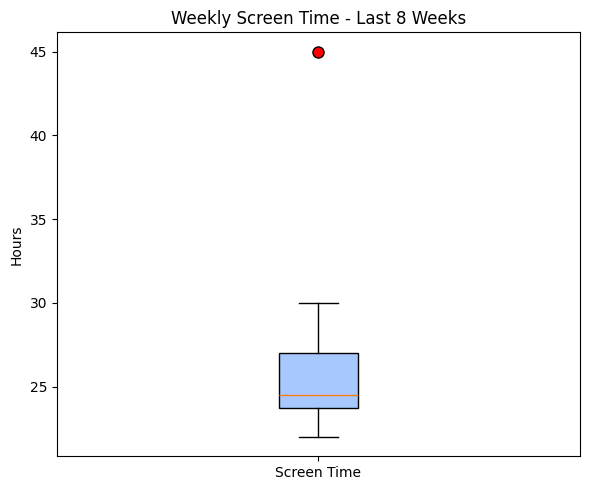

Screen time (hrs): [22, 25, 24, 30, 23, 45, 26, 24]


In [7]:
screen_time = [22, 25, 24, 30, 23, 45, 26, 24]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(screen_time, vert=True, patch_artist=True,
           boxprops=dict(facecolor='#a6c8ff'),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
ax.set_title('Weekly Screen Time - Last 8 Weeks')
ax.set_ylabel('Hours')
ax.set_xticklabels(['Screen Time'])

plt.tight_layout()
plt.show()

print('Screen time (hrs):', screen_time)

**Interpretation:** Week 6's **45 hours** shows up as the red outlier point — well above the rest of the weeks, which cluster between 22 and 30 hours. That one week aside, weekly screen time is fairly steady.